Nuestro objetivo es analizar y extraer información valiosa y estrategica de la base de datos NorthWind.

In [7]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os
import seaborn as sbn

In [8]:
base_dir = os.path.dirname(os.getcwd())
db_path = os.path.join(base_dir, "data", "Northwind.db")

conn = sqlite3.connect(db_path)

Creamos la conexión con la base de datos NorthWind.

In [9]:
#Clientes
query1 = '''
         SELECT c.CustomerName AS NombreCliente, SUM(od.Quantity) as UnidadesVendidas, sum(od.Quantity * p.Price) AS Monto FROM Customers c
        JOIN Orders o ON c.CustomerID = o.CustomerID
        JOIN OrderDetails od ON o.OrderID = od.OrderID
        JOIN Products P ON od.ProductID = p.ProductID
        GROUP BY c.CustomerName
        ORDER BY Monto DESC
        '''
clientes_ventas = pd.read_sql_query(query1, conn)
print(clientes_ventas)

                         NombreCliente  UnidadesVendidas     Monto
0                         Ernst Handel              1418  35631.21
1                       Mère Paillarde               422  23362.60
2                   Save-a-lot Markets               775  22500.06
3           Rattlesnake Canyon Grocery               573  18421.42
4                           QUICK-Stop               839  18178.80
..                                 ...               ...       ...
69              Océano Atlántico Ltda.                24    399.00
70                     Du monde entier                13    336.00
71          Centro comercial Moctezuma                11    126.00
72  Ana Trujillo Emparedados y helados                 6    111.00
73                      Franchi S.p.A.                 2     62.46

[74 rows x 3 columns]


Se hizo una consulta a la base de datos para ver el monto en ventas por ventas por cliente y la cantidad de unidades que han comprado.

In [10]:
print(clientes_ventas.info)
print(clientes_ventas.index.duplicated().any())
print(clientes_ventas.isna().sum())


<bound method DataFrame.info of                          NombreCliente  UnidadesVendidas     Monto
0                         Ernst Handel              1418  35631.21
1                       Mère Paillarde               422  23362.60
2                   Save-a-lot Markets               775  22500.06
3           Rattlesnake Canyon Grocery               573  18421.42
4                           QUICK-Stop               839  18178.80
..                                 ...               ...       ...
69              Océano Atlántico Ltda.                24    399.00
70                     Du monde entier                13    336.00
71          Centro comercial Moctezuma                11    126.00
72  Ana Trujillo Emparedados y helados                 6    111.00
73                      Franchi S.p.A.                 2     62.46

[74 rows x 3 columns]>
False
NombreCliente       0
UnidadesVendidas    0
Monto               0
dtype: int64


No hay registros duplicados, ni valores faltantes, por lo que no es necesario algún método de inputación. 

In [44]:
print(clientes_ventas["Monto"].describe())
monto_total = clientes_ventas["Monto"].sum()
print("Monto total", monto_total)

count       74.000000
mean      5221.949054
std       6747.855188
min         62.460000
25%        950.142500
50%       2381.500000
75%       5756.100000
max      35631.210000
Name: Monto, dtype: float64
Monto total 386424.23000000004


Podemos destacar que el monto promedio de ventas por cliente es de $5221.94 USD, la desvisción estandar de $6747.85 USD, un monto máximo correspondiente a Ernst Handel de $35631.21 USD y uno mínimo correspondiente a Franchi S.p.A. de $62.46 USD. También notamos que nuestra distancia intercuartil es de $4805.95 USD y el MONTO TOTAL es de $386424.23 USD.

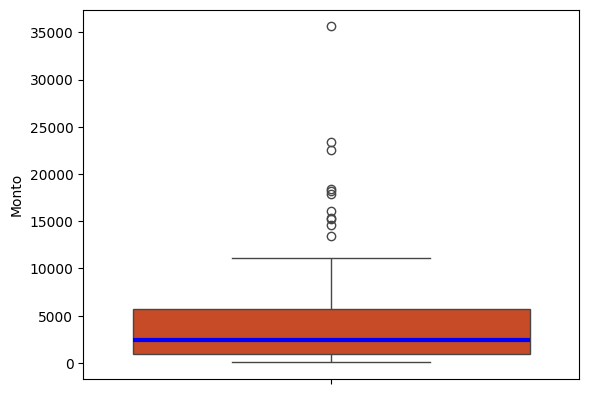

In [45]:
sbn.boxplot(clientes_ventas["Monto"], orient='v', color="#E23D0B", medianprops={'color':'blue', 'linewidth': 3})
plt.show()

En la gráfica anterior podemos notar que la mayoría de los datos se quedan cerca a la media y también podemos ver algunos valores atípicos acorrespondientes a los mayores compradores.

                  NombreCliente     Monto
0                  Ernst Handel  35631.21
1                Mère Paillarde  23362.60
2            Save-a-lot Markets  22500.06
3    Rattlesnake Canyon Grocery  18421.42
4                    QUICK-Stop  18178.80
5                 Queen Cozinha  17880.60
6              Piccolo und mehr  16040.75
7  Hungry Owl All-Night Grocers  15391.02
8          Blondel père et fils  15253.75
9                 Simons bistro  14619.00
El monto acumulado de los mejores 10 clientes es de:  197279.21000000002


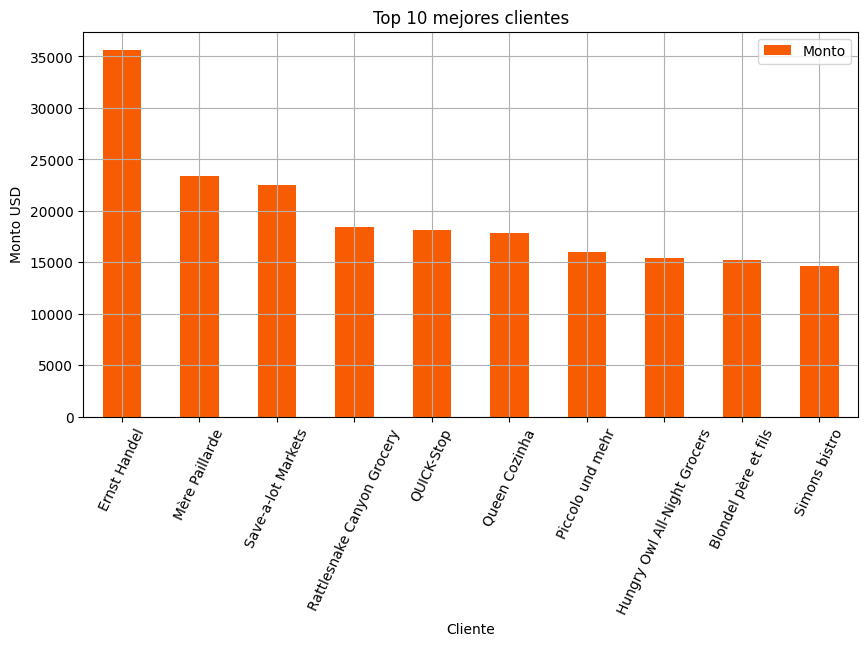

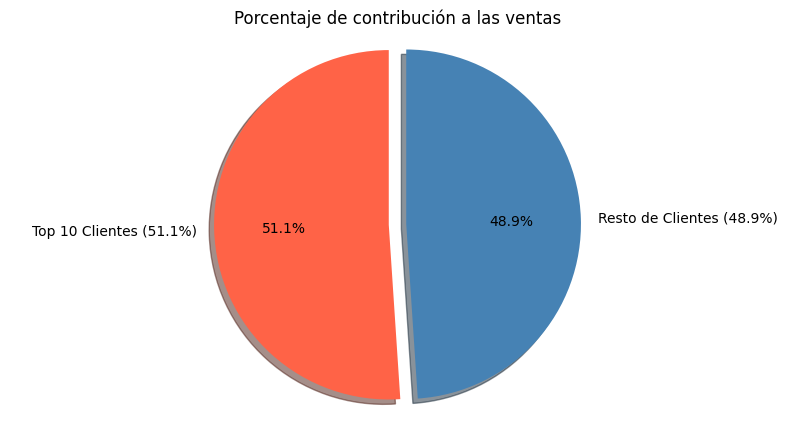

In [52]:
top10_clientes = clientes_ventas[["NombreCliente", "Monto"]].head(10)
print(top10_clientes)
Monto_top10 = top10_clientes["Monto"].sum()
print("El monto acumulado de los mejores 10 clientes es de: ", Monto_top10)
Monto_resto_clientes = monto_total - Monto_top10

#Gráfica de los 10 mejores clientes
top10_clientes.plot(x='NombreCliente', y='Monto', figsize=(10, 5), color="#F85C02", kind='bar')
plt.title("Top 10 mejores clientes")
plt.grid()
plt.xlabel("Cliente")
plt.ylabel("Monto USD")
plt.xticks(rotation=65)
plt.show()

#Gráfica porcentajes
plt.figure(figsize=(10, 5))
plt.pie([Monto_top10, Monto_resto_clientes], explode = (0.1, 0), 
        labels=[f"Top 10 Clientes ({(Monto_top10 / monto_total) * 100:.1f}%)", 
                f"Resto de Clientes ({(Monto_resto_clientes / monto_total) * 100:.1f}%)"],
        colors = ['#FF6347', '#4682B4'], autopct='%1.1f%%', shadow=True, startangle=90 )
plt.title("Porcentaje de contribución a las ventas")
plt.axis('equal') 
plt.show()


Podemos observar nuestros 10 mejores clintes de los cuales el cliente que más ha comprado es Ernst Handel con $35631.21 USD. También notemos que la suma del monto de los 10 mejores clientes es de $197279.21 USD que representa un 51.1% de las ventas totales.

In [13]:
print(clientes_ventas["UnidadesVendidas"].describe())

count      74.000000
mean      172.202703
std       223.491410
min         2.000000
25%        45.750000
50%        97.500000
75%       189.750000
max      1418.000000
Name: UnidadesVendidas, dtype: float64


Ahora podemos notar que en promedio los clientes han comprado 172 articulos y la desviación estandar es de 223 lo cual es alta, lo que hace nos dice que hay clientes que compran mucho pero también hay clientes casuales. Hay un máximo de 1418 articlulos comprados y un mínimo de 2.